In [1]:
# Check if lower threshold save tokens end2end
import numpy as np
import json
import matplotlib.pyplot as plt

# use retina mode for better resolution
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 150

from tqdm import tqdm

from signal_util import (
    ema_causal, load_log, exit_time_first_geq, exit_time_first_leq,
    exit_time_lower_threshold
)

from risk_control_utils import (
    threshold_to_loss_vectorized_upper, threshold_to_loss_vectorized_lower, find_threshold, 
    sigmoid_func
)

from risk_control_utils import (
    lower_threshold_correctness_risk_v2, efficiency_loss_v1, sigmoid_func,
    lower_threshold_correctness_risk_v1, efficiency_loss_v2
)

def lower_threshold_losses(entry, signal_type, c_values, shift, upper_bound, alpha=0.1):
    signal = entry[signal_type]
    if signal_type in ('eat_uni_forced', 'entropy_uni'):
        signal = 1 - signal
    signal = ema_causal(signal, alpha=alpha)
    thresholds = sigmoid_func(
        entry['tokens_used'],
        shift=shift,
        c=c_values.reshape(-1, 1),
        upper_bound=upper_bound,
    )
    exit_times = exit_time_lower_threshold(signal, thresholds)
    correctness_loss = lower_threshold_correctness_risk_v1(
        entry['intermediate_correct'], exit_times
    ).astype(np.float32)
    efficiency_loss = efficiency_loss_v2(
        entry['intermediate_correct'], exit_times
    ).astype(np.float32)
    return correctness_loss, efficiency_loss


def exponential_moving_average(data, timescale, ema_0=0.0, debias=False):
    data = np.asarray(data, dtype=float)
    ema = np.zeros_like(data, dtype=float)
    
    beta = 1.0 - timescale  # decay for previous EMA

    # step t = 1 (index 0)
    ema[0] = timescale * data[0] + beta * ema_0

    if debias:
        ema_debiased = np.zeros_like(ema, dtype=float)
        # bias correction factor: 1 - beta^t, here t = 1
        correction = 1.0 - beta**1
        ema_debiased[0] = ema[0] / correction

    # t = i+1 in the usual EMA notation
    for i in range(1, len(data)):
        ema[i] = timescale * data[i] + beta * ema[i - 1]

        if debias:
            correction = 1.0 - beta**(i + 1)
            ema_debiased[i] = ema[i] / correction

    return ema_debiased if debias else ema


def exponential_moving_variance(data, timescale, ema_0=0.0, debias=False):
    data = np.asarray(data, dtype=float)
    beta = 1.0 - timescale

    # First, EMA of the mean (can be biased; variance debias happens below)
    ema_mean = exponential_moving_average(data, timescale, ema_0=0.0, debias=False)

    ema_variance = np.zeros_like(data, dtype=float)
    ema_variance[0] = ema_0

    if debias:
        var_debiased = np.zeros_like(data, dtype=float)
        # At t = 1, we just applied the first update below (in the loop)
        # so we start debiasing from i = 0 after the loop update

    for i in range(1, len(data)):
        deviation = data[i] - ema_mean[i]
        ema_variance[i] = timescale * (deviation ** 2) + beta * ema_variance[i - 1]

        if debias:
            correction = 1.0 - beta**(i + 1)
            var_debiased[i] = ema_variance[i] / correction

    if debias:
        # var_debiased[0] stays at 0.0 if ema_0 = 0.0 (no information yet)
        var_debiased[0] = ema_variance[0]
        return var_debiased
    else:
        return ema_variance

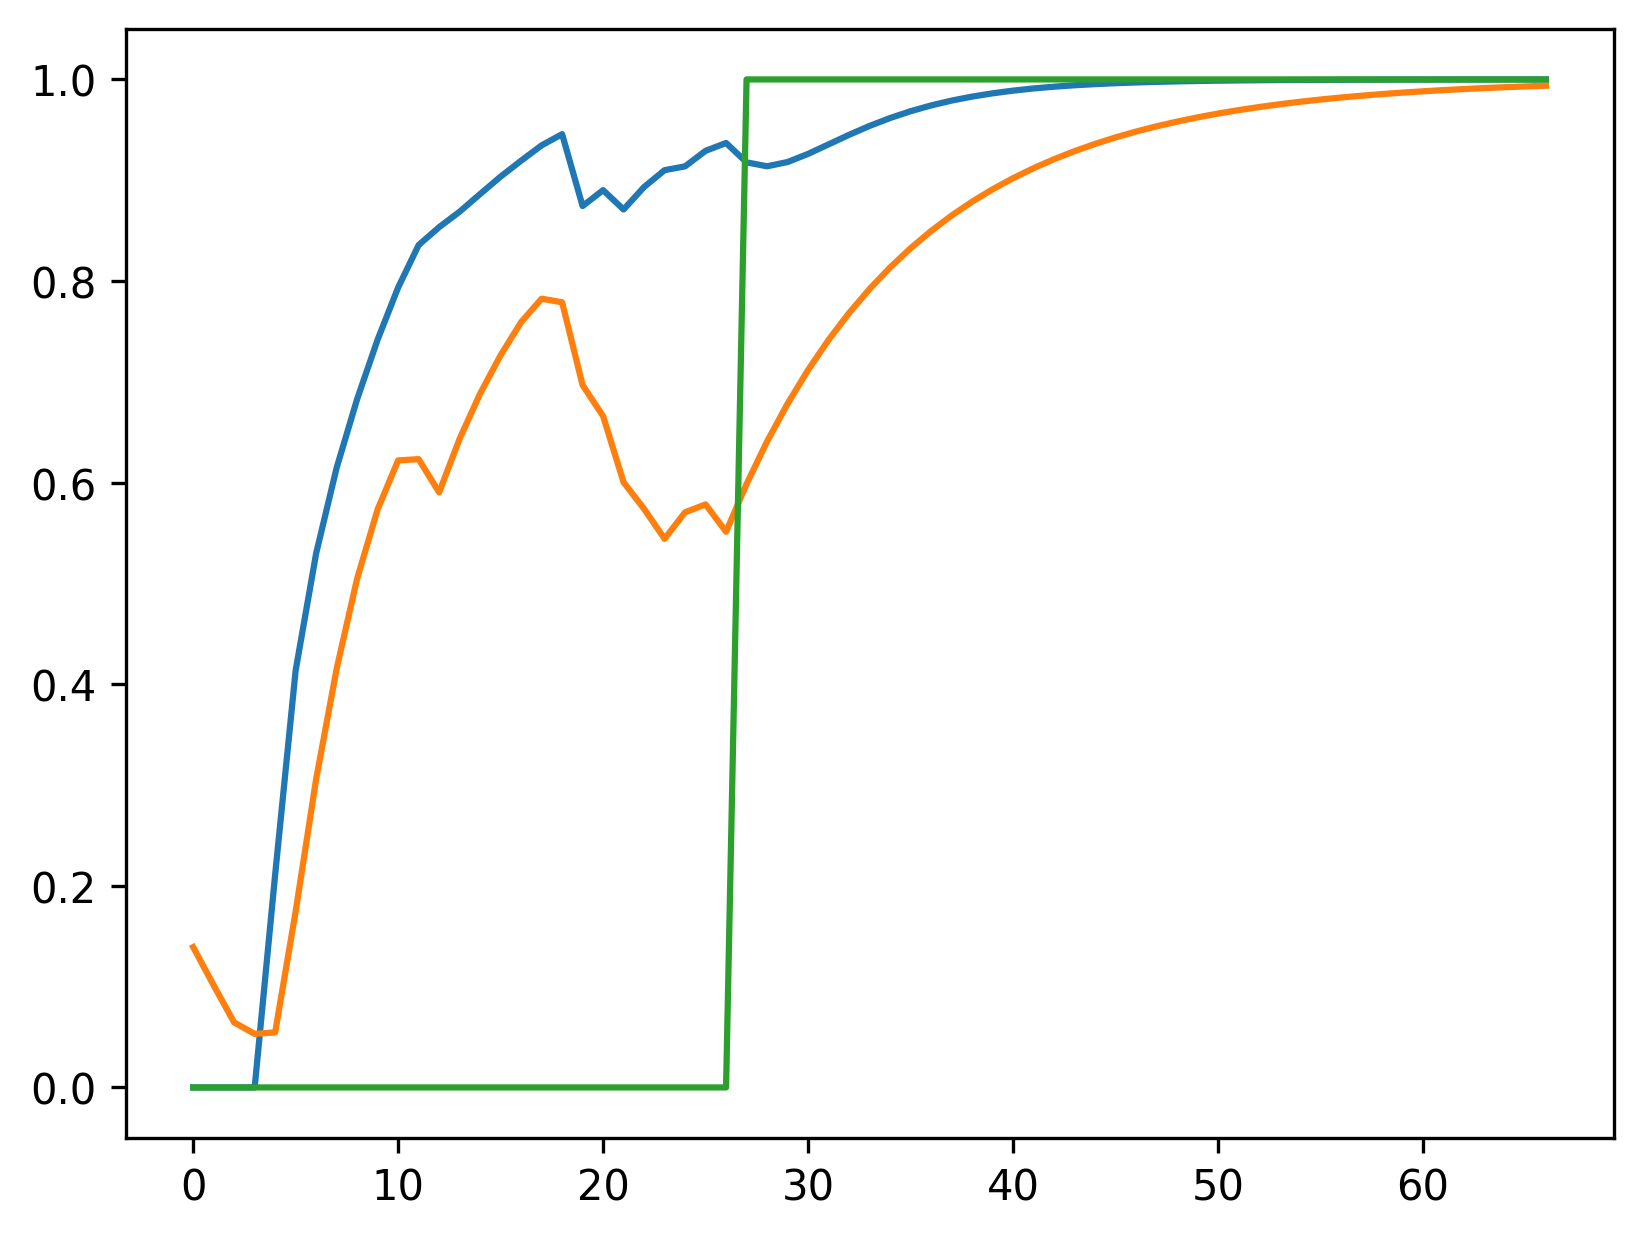

In [282]:
idx = 64
signal_name = 'entropy_uni'
F = lambda x: np.maximum(1 - exponential_moving_variance(x, timescale=0.2, ema_0=1.0, debias=True), 0)
F1 = lambda x: np.maximum(1 - exponential_moving_average(x, timescale=0.1, ema_0=0.0, debias=True), 0)
plt.plot(F(val_data[idx][signal_name]))
plt.plot(F1(val_data[idx][signal_name]))
plt.plot(val_data[idx]['intermediate_correct'])

In [ ]:
dir = "PATH TO LOG"  # --- IGNORE ---
all_log = load_log(dir)
# Test validation split
split_size = 0.2
# seed = 42
seed = 49
# seed = 52
np.random.seed(seed)
indices = np.random.permutation(len(all_log))
split_idx = int(split_size * len(all_log))
val_indices, test_indices = indices[:split_idx], indices[split_idx:]
val_data = [all_log[i] for i in val_indices]
test_data = [all_log[i] for i in test_indices]

thresholds_2 = np.arange(0.0, 30000, 200)
# Check baseline
correctness_list_baseline = []
token_usage_list_baseline = []
for item in test_data:
    correctness = np.array(item['intermediate_correct'])
    token_usage = np.array(item['tokens_used'])
    exit_pos = exit_time_first_geq(token_usage, thresholds_2)
    correctness_list_baseline.append(correctness[exit_pos])
    token_usage_list_baseline.append(token_usage[exit_pos])

correctness_array = np.array(correctness_list_baseline)
baseline_accuracy = correctness_array.mean(0)
token_usage_array_baseline = np.array(token_usage_list_baseline)

epsilons = np.arange(0.0, 1.0, 0.001)
thresholds = np.arange(0.0, 1.0, 0.001)
thresholds = 1 - np.array([2 ** (-i) for i in range(40)] + list(thresholds))
# signal_name = 'entropy_uni'
signal_name = 'confidence'
all_correctness_losses, all_efficiency_losses = [], []
F = lambda x: np.maximum(1 - exponential_moving_variance(x, timescale=0.1, ema_0=1.0, debias=True), 0)
# F = lambda x: np.maximum(1 - exponential_moving_average(x, timescale=0.2, ema_0=0.0, debias=True), 0)
# Upper threshold v.s. loss
for item in val_data:
    correctness_loss, efficiency_loss = threshold_to_loss_vectorized_upper(
        item,
        thresholds,
        exit_time_first_geq,
        signal_field=signal_name,
        correctness_field='intermediate_correct',
        signal_transform_fn=F
    )
    all_correctness_losses.append(correctness_loss)
    all_efficiency_losses.append(efficiency_loss)

all_correctness_losses = np.stack(all_correctness_losses, axis=0).mean(0)  # (num_items, num_thresholds)
all_efficiency_losses = np.stack(all_efficiency_losses, axis=0).mean(0)

method = 'UCB'
eps_to_threshold_upper = {}
for eps in epsilons:
    t, losses = find_threshold(
        thresholds,
        all_correctness_losses,
        all_efficiency_losses,
        epsilon=eps,
        method=method
    )
    eps_to_threshold_upper[eps] = t

all_thresholds_upper = [
    eps_to_threshold_upper[eps] for eps in epsilons if eps_to_threshold_upper[eps] >= 0
]
filtered_epsilons = [
    eps for eps in epsilons if eps_to_threshold_upper[eps] >= 0
]
correctness_list, token_usage_list = [], []
for item in test_data:
    correctness = np.array(item['intermediate_correct'])
    token_usage = np.array(item['tokens_used'])
    signal = F(np.array(item[signal_name]))
    exit_positions = exit_time_first_geq(
        signal,
        np.array(all_thresholds_upper)
    )
    # set min exit position as min(50, seq_len)
    # exit_positions = np.maximum(exit_positions, np.minimum(50, len(signal)-1))
    correctness_list.append(correctness[exit_positions])
    token_usage_list.append(token_usage[exit_positions])
correctness_array = np.array(correctness_list)
test_accuracies_upper = correctness_array.mean(0)
token_usage_array = np.array(token_usage_list)
test_token_usages_upper = token_usage_array.sum(0)



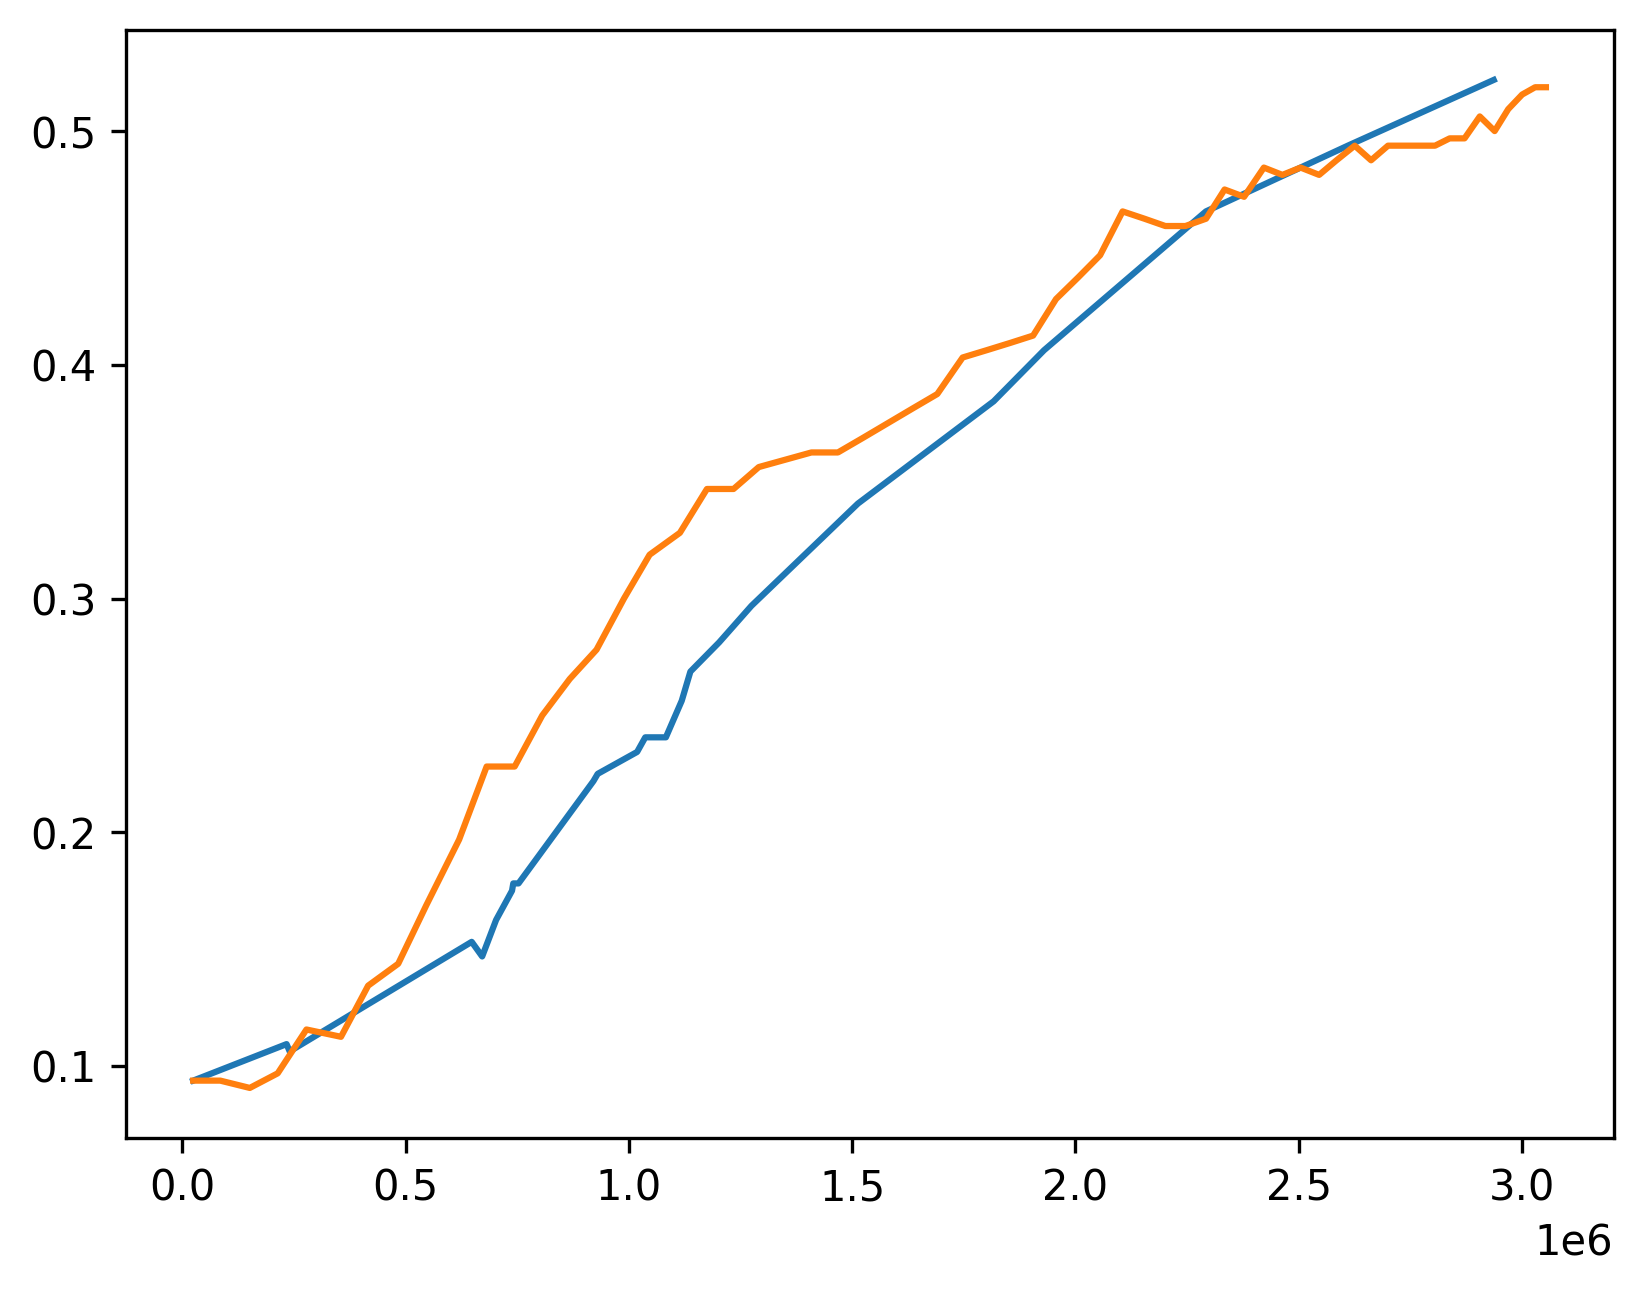

In [315]:
plt.plot(test_token_usages_upper, test_accuracies_upper)
plt.plot(token_usage_array_baseline.sum(0), baseline_accuracy)

In [318]:
lower_threshold_funcs = []
shifts = np.linspace(0, 20000, 25)          # length 50
base = np.linspace(-2.0, 0.0, 20)
cs     = np.linspace(0.0, 0.01, 100, endpoint=True) # length 50

S, C, base = np.meshgrid(shifts, cs, base, indexing="ij")  # both shape (50, 50)

shift_grid = S.reshape(-1, 1)  # (2500, 1)
c_grid     = C.reshape(-1, 1)  # (2500, 1)
base_grid = base.reshape(-1, 1)  # (1, 5)

# UPPER = np.unique(all_thresholds_upper)[-1]
UPPER = 0.9995
warmup_phase = 200

all_correctness_losses, all_efficiency_losses = [], []
for item in val_data:
    tokens = np.array(item['tokens_used'])
    signal = F(np.array(item[signal_name]))
    all_funcs = sigmoid_func(
        tokens,
        upper_bound=UPPER,
        # upper_bound=0.9
        lower=base_grid,
        c=c_grid,
        shift=shift_grid,
    )
    if max(tokens) < warmup_phase:
        target_idx = len(tokens)
    else:
        target_idx = np.where(tokens >= warmup_phase)[0][0]
    all_funcs[:, :target_idx] = -1.0
    exit_times = exit_time_lower_threshold(signal, all_funcs)
    # exit_times = np.maximum(exit_times, np.minimum(50, len(signal)-1))
    correctness_loss = lower_threshold_correctness_risk_v1(
        item['intermediate_correct'], exit_times
    ).astype(np.float32)
    efficiency_loss = efficiency_loss_v1(
        item['intermediate_correct'], exit_times
    ).astype(np.float32)
    all_correctness_losses.append(correctness_loss)
    all_efficiency_losses.append(efficiency_loss)
all_correctness_losses = np.stack(all_correctness_losses, axis=0).mean(0)  # (num_items, num_thresholds)
all_efficiency_losses = np.stack(all_efficiency_losses, axis=0).mean(0)
# Do risk control

lower_threshold_funcs = []
epsilons = np.arange(0.0, 1.0, 0.005)
valid_epsilons = []
for i, epsilon in enumerate(epsilons):
    # Do risk control
    method = 'UCB'
    t, losses = find_threshold(
        np.arange(len(shift_grid)),
        all_correctness_losses,
        all_efficiency_losses,
        epsilon=epsilon,
        method=method
    )
    if t == -1:
        # lower_threshold_funcs.append(np.array([shift_grid[-1], c_grid[-1], base_grid[-1]]).squeeze())
        continue
    else:
        valid_epsilons.append(epsilon)
        lower_threshold_funcs.append(np.array([shift_grid[t], c_grid[t], base_grid[t]]).squeeze())
lower_threshold_funcs_param = np.array(lower_threshold_funcs)  # (num_upper_thresholds, 2)

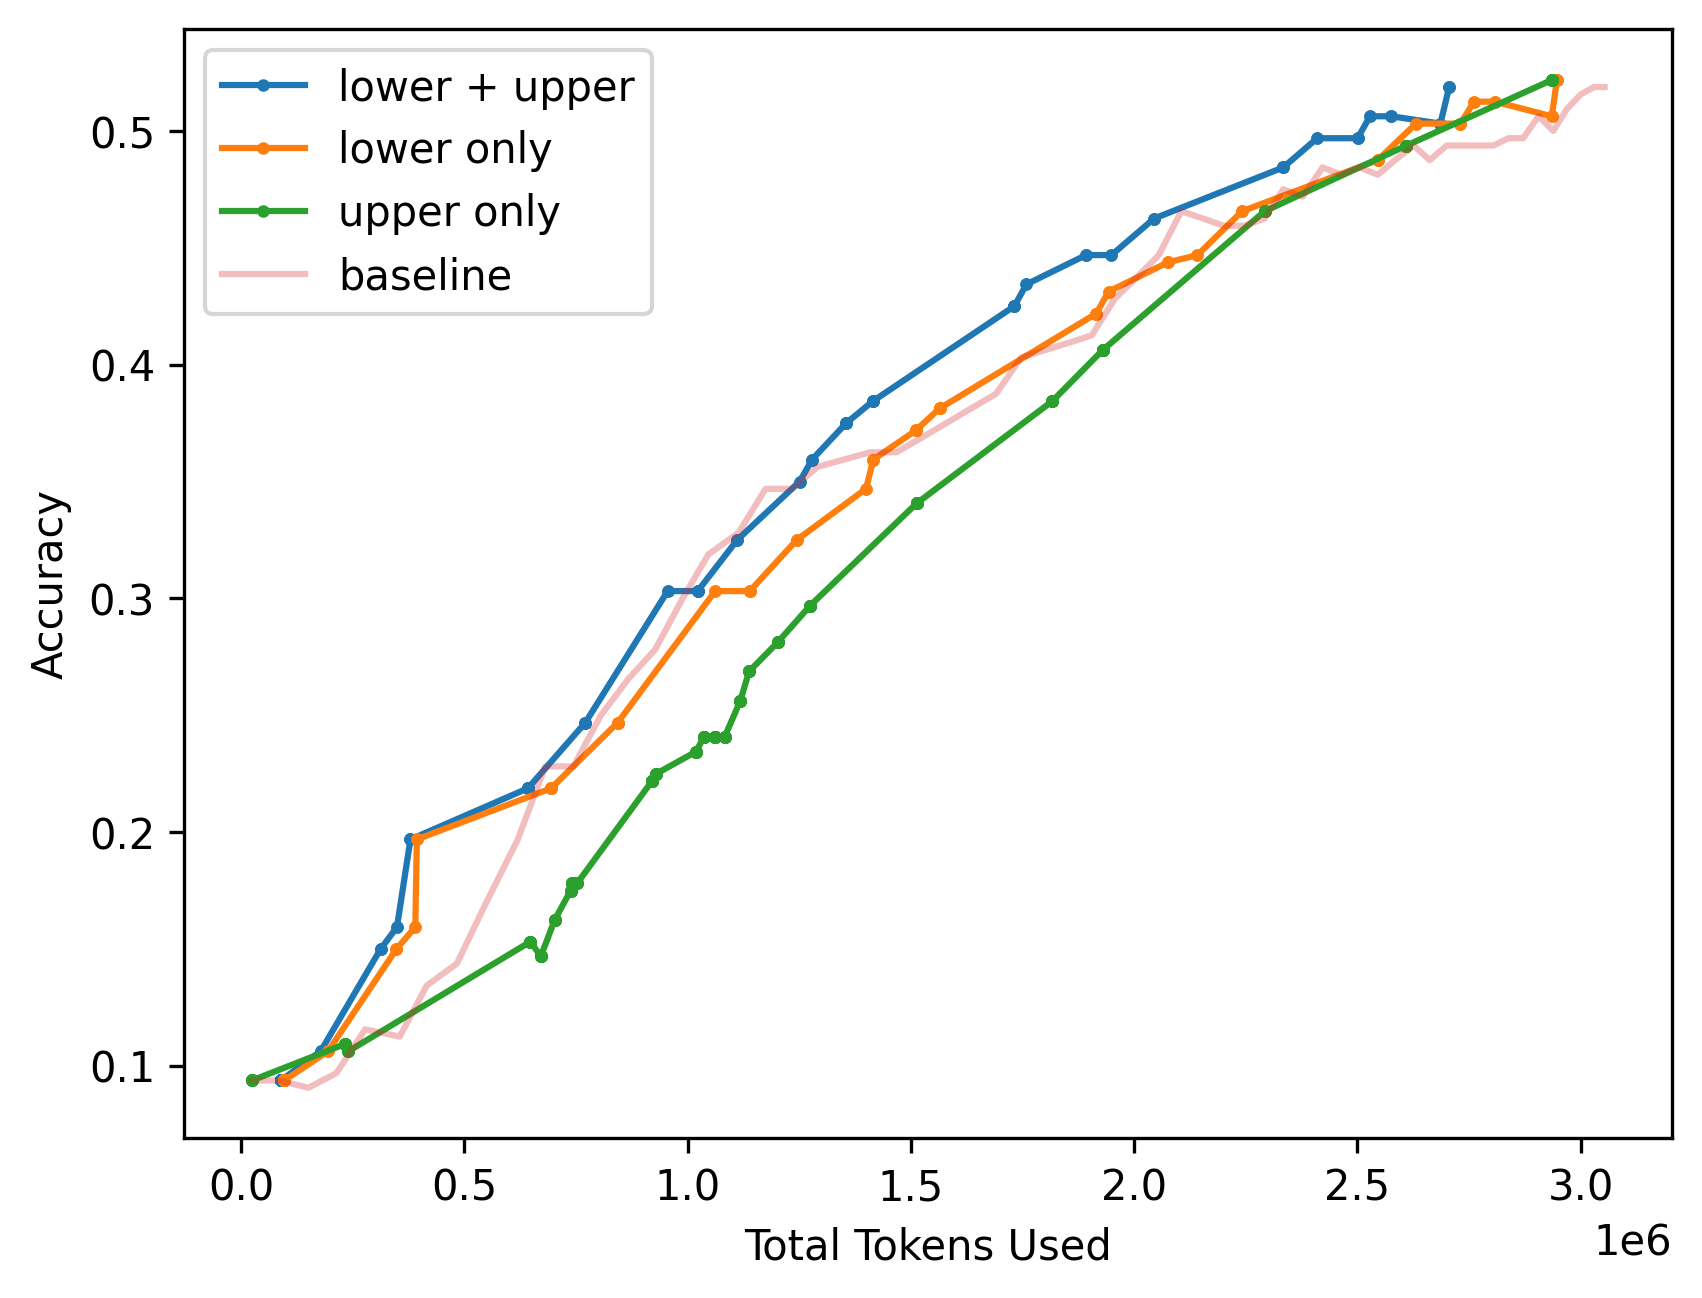

In [319]:
correctness_list, token_usage_list = [], []
correctness_lower_only, token_usage_list_lower_only = [], []
exit_type = []
for item in test_data:
    correctness = np.array(item['intermediate_correct'])
    token_usage = np.array(item['tokens_used'])
    signal = F(np.array(item[signal_name]))
    lower_threshold_funcs = sigmoid_func(
        token_usage,
        shift=lower_threshold_funcs_param[:, 0].reshape(-1, 1),
        upper_bound=UPPER,
        c=lower_threshold_funcs_param[:, 1].reshape(-1, 1),
        lower=lower_threshold_funcs_param[:, 2].reshape(-1, 1)
    )
    if max(token_usage) < warmup_phase:
        target_idx = len(token_usage)
    else:
        target_idx = np.where(token_usage >= warmup_phase)[0][0]
    lower_threshold_funcs[:, :target_idx] = -1.0
    exit_positions_lower = exit_time_lower_threshold(
        signal,
        lower_threshold_funcs
    )
    # all_lower_exit_positions.append(exit_positions_lower)
    correctness_lower_only.append(correctness[exit_positions_lower])
    token_usage_list_lower_only.append(token_usage[exit_positions_lower])
    exit_positions = exit_positions_lower
    exit_positions_upper = exit_time_first_geq(
        signal,
        np.array([UPPER])
    )
    exit_positions = np.minimum(exit_positions_lower, exit_positions_upper)

    from_lower   = (exit_positions_lower < exit_positions_upper)
    from_upper = (exit_positions_upper < exit_positions_lower)
    from_tie   = (exit_positions == len(signal) - 1)
    exit_type.append((from_lower, from_upper, from_tie))

    correctness_list.append(correctness[exit_positions])
    token_usage_list.append(token_usage[exit_positions])

test_accuracies_lower_upper = np.array(correctness_list).mean(0)
test_token_usages_lower_upper = np.array(token_usage_list).sum(0)

test_accuracies_lower = np.array(correctness_lower_only).mean(0)
test_token_usages_lower = np.array(token_usage_list_lower_only).sum(0)

plt.plot(test_token_usages_lower_upper, test_accuracies_lower_upper, label='lower + upper', marker='o', markersize=2)
plt.plot(test_token_usages_lower, test_accuracies_lower, label='lower only', marker='o', markersize=2)
plt.plot(test_token_usages_upper, test_accuracies_upper, label='upper only', marker='o', markersize=2)
plt.xlabel('Total Tokens Used')
plt.ylabel('Accuracy')
plt.plot(token_usage_array_baseline.sum(0), baseline_accuracy, label='baseline', alpha=0.3)
plt.legend()


0.496875


/tmp/ipykernel_1513337/1380598364.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_yticklabels(["Unsolv.", "Solv."][::-1])


0.055


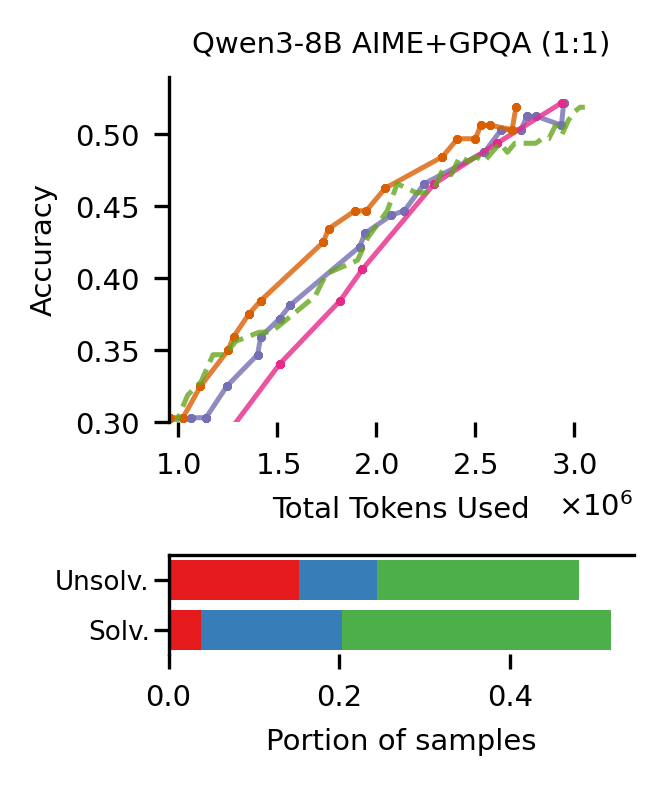

In [179]:
from matplotlib import ticker as mticker

fig, axs = plt.subplots(2, 1, figsize=(2.0, 2.5),
gridspec_kw={"height_ratios": [3.5, 1]},)
fig.subplots_adjust(hspace=0.6)


ax = axs[0]
line_config = {'linewidth': 1.2, 'alpha': 0.8}
FONTSIZE = 7
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in [1, 2, 3, 4]]

ax.plot(test_token_usages_lower, test_accuracies_lower, label='Lower only', marker='o', markersize=1, c=colors[1], **line_config)
ax.plot(test_token_usages_upper, test_accuracies_upper, label='Upper only', marker='o', markersize=1, c=colors[2], **line_config)
ax.plot(test_token_usages_lower_upper, test_accuracies_lower_upper, label='Lower + upper', marker='o', markersize=1, c=colors[0], **line_config)

ax.plot(token_usage_array_baseline.sum(0),
baseline_accuracy, alpha=0.8, linestyle='--',
# color='black',
c=colors[3],
 label='Token-based\n(Baseline)',   linewidth=1.2)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# a.plot([0, 1], [0, 1], linestyle='--', color='gray', label='y=x')
ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)
formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1)) 
ax.xaxis.set_major_formatter(formatter)
# ax.legend(fontsize=FONTSIZE)
ax.get_xaxis().get_offset_text().set_fontsize(7)
ax.set_xlabel('Total Tokens Used', fontsize=FONTSIZE)
ax.set_ylabel('Accuracy', fontsize=FONTSIZE)
ax.set_title(
    'Qwen3-8B AIME+GPQA ({})'.format(ratio_str), fontsize=FONTSIZE
)

ax.set_xlim(0.95e6, 3.3e6)
ax.set_ylim(0.3, 0.54)

# ax.set_xlim(1.5e6, 3.0e6)
# ax.set_ylim(0.5, 0.75)


# ax.set_xlim(0.8e6, 3.2e6)
# ax.set_ylim(0.1, 0.29)

cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in [0, 1, 2]]
FONTSIZE = 7


ax = axs[1]
solvable_indices = np.array([
    i for i, item in enumerate(test_data) if item['solvable']
])
unsolvable_indices = np.array([
    i for i, item in enumerate(test_data) if not item['solvable']
])

exit_type = np.array(exit_type).astype(int)
IDX = 50
E = exit_type[: , :, IDX]
print(test_accuracies_lower_upper[IDX])
solvable_E_num, nonsolvable_E_num = len(solvable_indices) / len(test_data), len(unsolvable_indices) / len(test_data)
solvable_E, nonsolvable_E = E[solvable_indices] * solvable_E_num, E[unsolvable_indices] * nonsolvable_E_num
ax.barh(['Solvable', 'Unsolvable'], [solvable_E.mean(0)[0], nonsolvable_E.mean(0)[0]], label='Lower Threshold', color=colors[0])
ax.barh(['Solvable', 'Unsolvable'], [solvable_E.mean(0)[1], nonsolvable_E.mean(0)[1]], left=[solvable_E.mean(0)[0], nonsolvable_E.mean(0)[0]], label='Upper Threshold', color=colors[1])
ax.barh(['Solvable', 'Unsolvable'], [solvable_E.mean(0)[2], nonsolvable_E.mean(0)[2]], left=[solvable_E.mean(0)[0] + solvable_E.mean(0)[1], nonsolvable_E.mean(0)[0] + nonsolvable_E.mean(0)[1]], label='None', color=colors[2])
ax.set_xlabel('Portion of samples', fontsize=FONTSIZE)
for a in ax.get_xticklabels():
    a.set_fontsize(FONTSIZE)
for a in ax.get_yticklabels():
    a.set_fontsize(FONTSIZE * 0.9)

axs[1].set_yticklabels(["Unsolv.", "Solv."][::-1])
axs[1].tick_params(axis="y", pad=1) 

# Remove spines
# ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)


fig.savefig('figures/lower_vs_upper_{}.pdf'.format(ratio_str), bbox_inches='tight')


# ax.legend(bbox_to_anchor=(-0.05, 2.0), loc='upper left',
#     title='Exit Type', fontsize=FONTSIZE, title_fontsize=FONTSIZE, ncols=3,
#     handletextpad=0.2, columnspacing=0.5, frameon=False
# )
# ax.set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
print(valid_epsilons[IDX])
# fig.savefig('figures/exit_type_lower_threshold.pdf', bbox_inches='tight')

Legends saved as 'figures/legend_line_plot.pdf' and 'figures/legend_bar_plot.pdf'


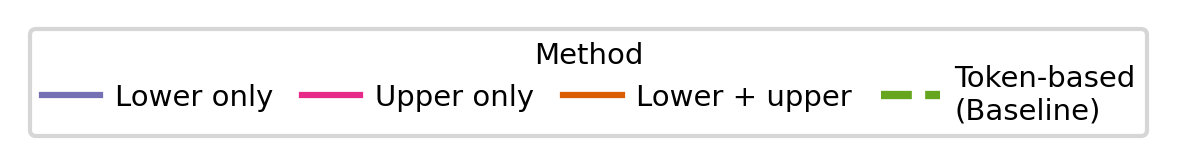

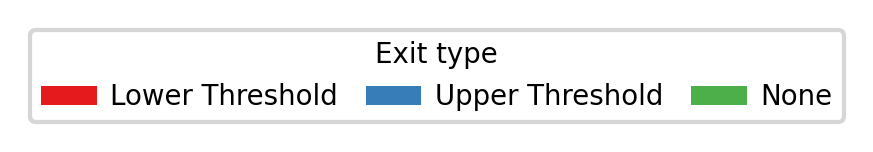

In [236]:
fig_legend_line, ax_legend_line = plt.subplots(figsize=(1, 0.1))
ax_legend_line.axis('off')
cmap = plt.get_cmap('Dark2')
colors = [cmap(i) for i in [1, 2, 3, 4]]
handles_line = [
    plt.Line2D([0], [0],  color=colors[1], markersize=5, label='Lower only'),
    plt.Line2D([0], [0],  color=colors[2], markersize=5, label='Upper only'),
    plt.Line2D([0], [0],  color=colors[0], markersize=5, label='Lower + upper'),
    plt.Line2D([0], [0], linestyle='--', color=colors[3], linewidth=2, label='Token-based\n(Baseline)'),
]
legend_line = ax_legend_line.legend(
    handles=handles_line, loc='center', fontsize=FONTSIZE, frameon=True,
    ncols=4, handletextpad=0.5, columnspacing=1.0, title='Method', title_fontsize=FONTSIZE,
    # titld_pad = 2
)
legend_line._legend_box.sep = -1.2
fig_legend_line.savefig('figures/legend_line_plot.pdf', bbox_inches='tight', pad_inches=0.0)
# plt.close(fig_legend_line)

# Create legend for bar plot (bottom subplot)
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in [0, 1, 2]]
fig_legend_bar, ax_legend_bar = plt.subplots(figsize=(1, 0.1))
ax_legend_bar.axis('off')
handles_bar = [
    plt.Rectangle((0, 0), 1, 1, fc=colors[0], label='Lower Threshold'),
    plt.Rectangle((0, 0), 1, 1, fc=colors[1], label='Upper Threshold'),
    plt.Rectangle((0, 0), 1, 1, fc=colors[2], label='None'),
]
legend_bar = ax_legend_bar.legend(
    handles=handles_bar, loc='center', fontsize=FONTSIZE * 0.95, frameon=True,
    ncols=3, handletextpad=0.5, columnspacing=1, title='Exit type', title_fontsize=FONTSIZE * 0.95
)
fig_legend_bar.savefig('figures/legend_bar_plot.pdf', bbox_inches='tight', pad_inches=0.0)
# plt.close(fig_legend_bar)

print("Legends saved as 'figures/legend_line_plot.pdf' and 'figures/legend_bar_plot.pdf'")